# Coral Bleaching Predictor — Baseline (Faithful to Paper + LazyPredict + K-Fold)

**Paper:** Madireddy, Bosch, & McCalla (2023). *Using machine learning to develop a global coral bleaching predictor.* Journal of Emerging Investigators, Vol 6.



## 1. Imports & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')


## 2. Load Dataset

⚠️ ไฟล์มี `'nd'` (no data) ที่ต้อง parse เป็น `NaN`


In [4]:
DATA_PATH = '../../PreviousDataset.csv'

data = pd.read_csv(DATA_PATH, na_values=['nd', 'NA', ''])
print(f"Raw shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Raw shape: (9665, 48)

First few rows:


,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,City_Town_3,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,NaN,3/26/2016,20160326,4.0,6.25,297.78,301.67,298.17,291.91,303.85,2.74,5.0,1.32,0.87,0.0,-3.210000,2.83,12.0,5.49,26.0,6.0,3.96,3.13,19.88,2.18,0.23,2.74,-9.52,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,NaN,3/26/2016,20160326,5.0,8.75,297.78,301.67,298.17,291.91,303.85,2.74,5.0,1.32,0.87,0.0,-3.210000,2.83,12.0,5.49,26.0,6.0,3.96,3.13,19.88,2.18,0.23,2.74,-9.52,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,NaN,3/27/2016,20160327,6.0,11.25,298.17,301.38,298.34,292.67,303.76,2.57,5.0,0.87,0.82,0.0,-2.701111,2.60,10.0,5.67,27.0,5.0,2.68,3.14,18.95,1.97,-0.03,2.57,-8.73,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,NaN,3/27/2016,20160327,5.0,25.00,298.21,301.56,298.37,292.01,304.04,2.52,5.0,1.07,0.81,0.0,-2.803333,3.44,8.0,5.27,25.0,5.0,3.65,2.89,18.05,1.86,0.17,2.52,-9.38,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,NaN,8/6/2017,20170806,2.0,1.00,296.48,296.38,298.47,291.83,304.54,2.70,4.0,1.76,0.93,0.0,-3.268571,3.15,17.0,6.12,30.0,7.0,3.84,3.56,21.17,2.54,-5.34,2.70,-9.88,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56


In [5]:
# Parse Date และสร้าง Year column
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['Year'] = data['Date'].dt.year

print(f"Year distribution:")
print(data.groupby('Year').size())

Year distribution:
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


## 3. Data Cleaning ตาม Paper

ตาม **Materials and Methods → Data Cleaning** ของ paper:

> *"all data points with negative SSTA were removed"*

⚠️ **Interpretation:** Paper เขียน "negative" แต่จากการทดลอง — ต้อง strict `SSTA > 0` (ตัด 0 ด้วย) ถึงจะได้ N=6,112 ตรงกับที่ paper รายงาน

> *"Bleaching events from these years [1998-2002] were also removed to allow an even distribution"*

> *"After data cleaning was completed, 6,112 bleaching events remained"*


In [6]:
# Step 1: ตัด SSTA <= 0
data['SSTA'] = pd.to_numeric(data['SSTA'], errors='coerce')
print(f"Before SSTA filter: {len(data)}")
data = data[data['SSTA'] > 0]
print(f"After SSTA > 0: {len(data)}")

# Step 2: ตัดปี 1998-2002
data = data[data['Year'] >= 2003]
print(f"After Year >= 2003: {len(data)}")

# Step 3: Drop categorical และ identifier columns
# - Categorical: Ocean, Realm, Ecoregion (paper บอกตัด)
# - Identifiers: ID, Date, Date2 (paper บอกใช้ lat/lon เป็น location numeric)
# - Location text: City_Town, City_Town_2, City_Town_3, State_Island_Province, Country_Name (NaN เยอะ)
drop_columns = ['ID', 'Ocean', 'Realm', 'Ecoregion',
                'Country_Name', 'State_Island_Province',
                'City_Town', 'City_Town_2', 'City_Town_3',
                'Date', 'Date2', 'Year']
data = data.drop(columns=[c for c in drop_columns if c in data.columns])

print(f"After drop categorical/ID columns: {data.shape}")

# Step 4: Coerce ทุก column ที่เหลือเป็น numeric (handle 'nd' values)
for c in data.columns:
    data[c] = pd.to_numeric(data[c], errors='coerce')

# Step 5: Drop rows ที่ target เป็น NaN
data = data.dropna(subset=['Average_Bleaching'])
print(f"After drop NaN target: {len(data)}")

print(f"\n>>> Final cleaned shape: {data.shape}")
print(f">>> Paper reports: 6,112 events")
print(f">>> Match: {'✅' if len(data) == 6112 else '❌'}")
assert len(data) == 6112, "Cleaned dataset should match the paper's 6,112 events."

Before SSTA filter: 9665
After SSTA > 0: 6162
After Year >= 2003: 6112
After drop categorical/ID columns: (6112, 37)
After drop NaN target: 6112

>>> Final cleaned shape: (6112, 37)
>>> Paper reports: 6,112 events
>>> Match: ✅


## 4. Feature Selection — Pearson Correlation Matrix

ตาม Figure 2 และ paper text:

> *"When parameters such as wind speed or thermal stress anomaly were found multicollinear (r > 0.8) to each other, **we removed both**"*

⚠️ **สำคัญ:** Paper บอกว่าตัด **ทั้งคู่** ของ multicollinear pair ไม่ใช่ตัดแค่ตัวเดียว


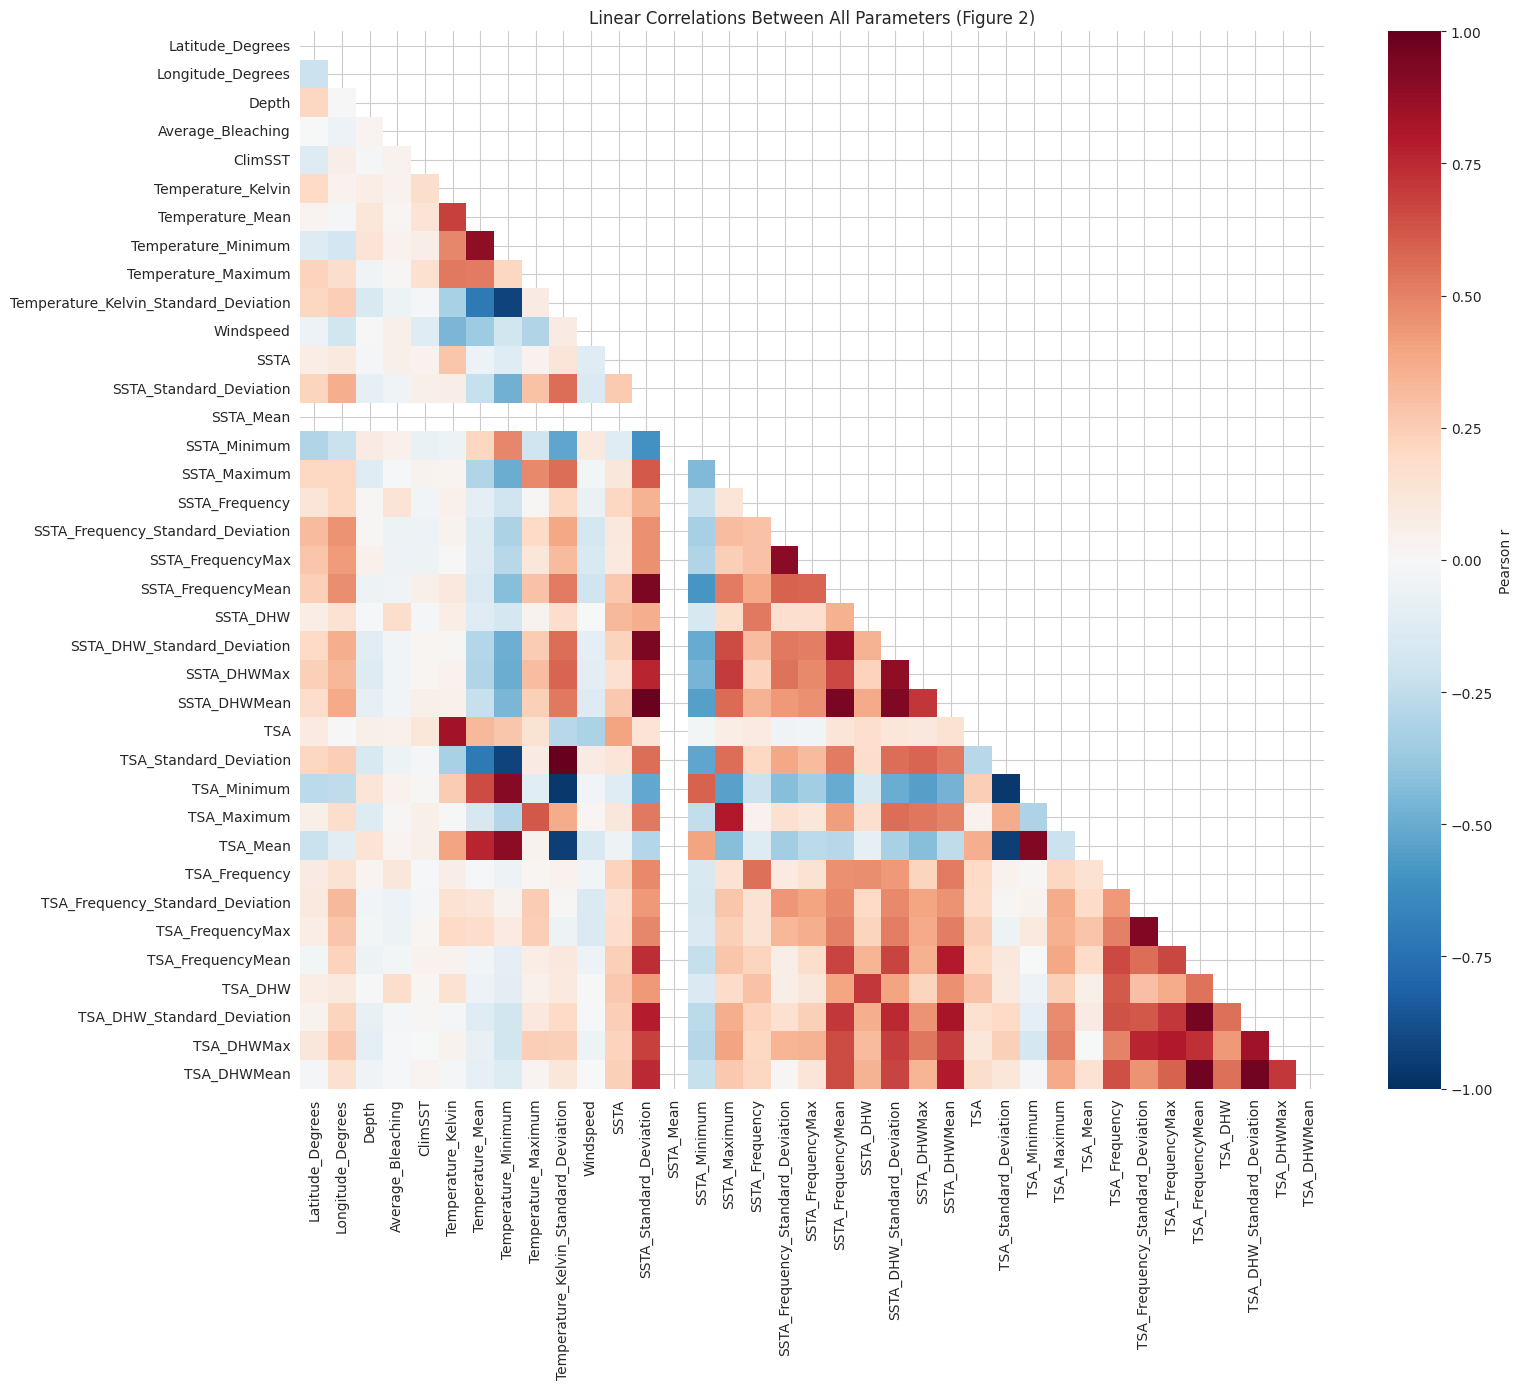

In [6]:
# Heatmap correlation ของทุก numeric feature (Figure 2)
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(data.corr(), dtype=bool))
sns.heatmap(data.corr(), mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
plt.title('Linear Correlations Between All Parameters (Figure 2)')
plt.tight_layout()
plt.show()

In [7]:
# Correlation กับ target
target_corr = data.corr()['Average_Bleaching'].drop('Average_Bleaching')
target_corr = target_corr.sort_values(key=abs, ascending=False)
print("Top 15 features correlated with Average_Bleaching:")
print(target_corr.head(15))

Top 15 features correlated with Average_Bleaching:
SSTA_DHW                                 0.176013
TSA_DHW                                  0.174344
SSTA_Frequency                           0.136499
TSA_Frequency                            0.116205
Longitude_Degrees                       -0.062058
SSTA                                     0.061674
Windspeed                                0.059772
TSA_Frequency_Standard_Deviation        -0.056946
SSTA_FrequencyMax                       -0.054985
SSTA_Frequency_Standard_Deviation       -0.049784
TSA_FrequencyMax                        -0.049604
TSA                                      0.049374
SSTA_Minimum                             0.048041
Temperature_Kelvin_Standard_Deviation   -0.047609
TSA_Standard_Deviation                  -0.047608
Name: Average_Bleaching, dtype: float64


### 5 Features ที่ paper เลือก (Figure 3)

หลัง drop multicollinear pairs ออกหมดแล้ว paper เหลือ 5 features:

| Feature | Pearson r vs bleaching | ทิศ |
|---|---|---|
| `SSTA` | +0.06 | บวก |
| `ClimSST` | +0.05 | บวก |
| `Depth` | +0.03 | บวก |
| `Latitude_Degrees` | -0.01 | ลบ |
| `Longitude_Degrees` | -0.06 | ลบ |


After dropping NaN in 5 features: N = 6112


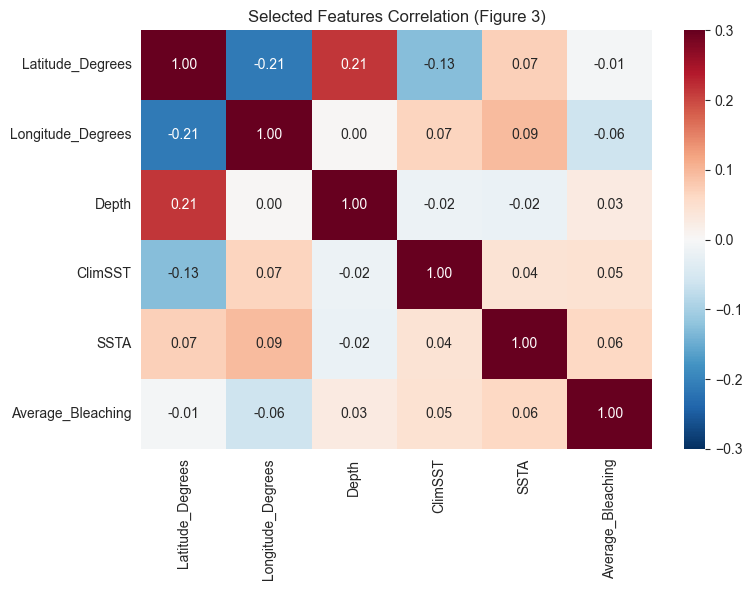

In [8]:
# 5 features ตาม paper
PAPER_FEATURES = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'ClimSST', 'SSTA']
TARGET = 'Average_Bleaching'

# Drop NaN ใน 5 features ที่จะใช้
data = data.dropna(subset=PAPER_FEATURES + [TARGET])
print(f"After dropping NaN in 5 features: N = {len(data)}")

# Heatmap เฉพาะ 5 features ที่เลือก + target (Figure 3)
plt.figure(figsize=(8, 6))
sns.heatmap(data[PAPER_FEATURES + [TARGET]].corr(),
            annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', vmin=-0.3, vmax=0.3)
plt.title('Selected Features Correlation (Figure 3)')
plt.tight_layout()
plt.show()

## 5. PCA Validation (Figure 4)

> *"Four components were needed for the PCA"*
> *"Four components crossed the 95% threshold recommended for PCA"*

ใช้ PCA เพื่อ **ยืนยัน** ว่า 5 features ที่เลือกไม่ multicollinear กันเอง
(ไม่ใช้ PCs เป็น input ของโมเดล — paper ใช้ PCA เป็น diagnostic เท่านั้น)


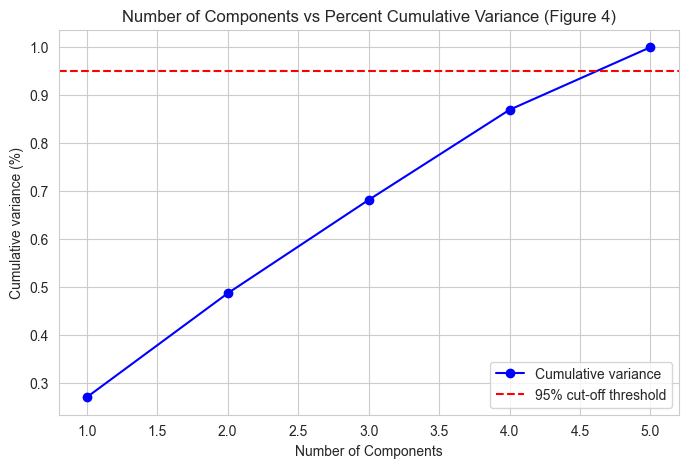

Cumulative explained variance:
  1 component(s): 0.2703
  2 component(s): 0.4870
  3 component(s): 0.6817
  4 component(s): 0.8696
  5 component(s): 1.0000 <-- ผ่าน 95%


In [9]:
# PCA บน 5 features ที่เลือก
X_for_pca = data[PAPER_FEATURES].values
X_scaled = StandardScaler().fit_transform(X_for_pca)

pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, 'b-o', label='Cumulative variance')
plt.axhline(0.95, color='red', linestyle='--', label='95% cut-off threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative variance (%)')
plt.title('Number of Components vs Percent Cumulative Variance (Figure 4)')
plt.legend()
plt.grid(True)
plt.show()

print("Cumulative explained variance:")
for i, v in enumerate(cum_var, 1):
    flag = " <-- ผ่าน 95%" if v >= 0.95 and (i == 1 or cum_var[i-2] < 0.95) else ""
    print(f"  {i} component(s): {v:.4f}{flag}")

## 6. Train/Test Split

ตาม paper text:
> *"Overall, 80% of the original dataset was used to train the model and the remaining 20% was used to test"*


In [10]:
X = data[PAPER_FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Train: {len(X_train)/len(X)*100:.0f}%, Test: {len(X_test)/len(X)*100:.0f}%")

Train: (4889, 5),  Test: (1223, 5)
Train: 80%, Test: 20%


## 7. LazyPredict Model Comparison (Optional)

ตาม paper มีการทดสอบหลาย model ด้วย `lazypredict` ก่อนเลือก Random Forest เพราะได้ R² สูงสุดและ RMSE ต่ำสุด

Cell นี้เป็น optional:
- ถ้ามี `lazypredict` ติดตั้ง จะรันและแสดง top models
- ถ้าไม่มี จะ skip และบอกคำสั่งติดตั้ง


In [11]:
try:
    from lazypredict.Supervised import LazyRegressor

    lazy_regressor = LazyRegressor(
        verbose=0,
        ignore_warnings=True,
        custom_metric=None
    )

    lazy_models, lazy_predictions = lazy_regressor.fit(
        X_train, X_test, y_train, y_test
    )

    print("LazyPredict model comparison (Top 15):")
    display(lazy_models.head(15))

except Exception as exc:
    lazy_models = None
    print("LazyPredict skipped.")
    print("ถ้าต้องการรัน cell นี้ ให้ติดตั้งก่อนด้วย: %pip install lazypredict")
    print(f"Reason: {type(exc).__name__}: {exc}")


LazyPredict model comparison (Top 15):


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.160472,0.163907,8.485946,3.331710
RandomForestRegressor,0.147262,0.150751,8.552449,3.874735
LGBMRegressor,0.146330,0.149823,8.557122,0.195063
HistGradientBoostingRegressor,0.125628,0.129206,8.660257,0.840911
BaggingRegressor,0.101231,0.104908,8.780248,1.373875
GradientBoostingRegressor,0.087023,0.090759,8.849373,1.996208
XGBRegressor,0.058536,0.062388,8.986373,0.320376
MLPRegressor,0.053193,0.057067,9.011837,5.772710
SGDRegressor,0.013470,0.017507,9.198940,0.030272


## 8. Random Forest Baseline

Hyperparameters จาก paper (GridSearchCV result):

| Parameter | Value |
|---|---|
| `n_estimators` | 300 |
| `max_depth` | 16 |
| `max_features` | `'sqrt'` |
| `criterion` | `'squared_error'` (เก่าใช้ `'mse'`) |


In [11]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    max_features='sqrt',
    criterion='squared_error',  # paper ใช้ 'mse' (sklearn เก่า)
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 9. Evaluate Model

**เป้าหมาย:**
- R² ≈ 0.25
- RMSE ≈ 7.91
- Accuracy ≈ 96%


In [12]:
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("BASELINE RESULTS (single seed = 42)")
print("=" * 50)
print(f"R²    = {r2:.4f}    (paper: 0.25)")
print(f"RMSE  = {rmse:.4f}    (paper: 7.91)")
print(f"MAE   = {mae:.4f}")
print(f"Accuracy (100 - MAE) = {100 - mae:.2f}%   (paper: 96%)")
print(f"\n⚠️  Single-seed result อาจแกว่ง — ดู multi-seed check ด้านล่าง")

BASELINE RESULTS (single seed = 42)
R²    = 0.1786    (paper: 0.25)
RMSE  = 8.4111    (paper: 7.91)
MAE   = 3.3869
Accuracy (100 - MAE) = 96.61%   (paper: 96%)

⚠️  Single-seed result อาจแกว่ง — ดู multi-seed check ด้านล่าง


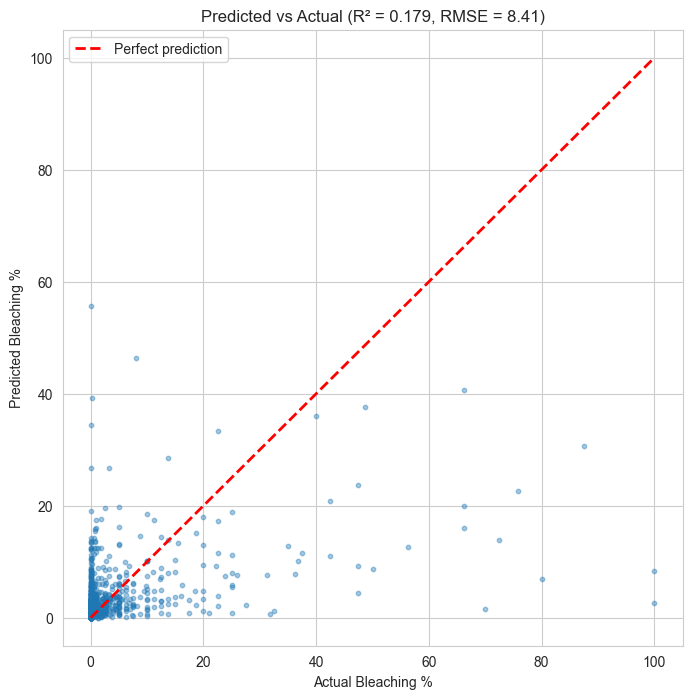

In [13]:
# Plot predicted vs actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Bleaching %')
plt.ylabel('Predicted Bleaching %')
plt.title(f'Predicted vs Actual (R² = {r2:.3f}, RMSE = {rmse:.2f})')
plt.legend()
plt.grid(True)
plt.show()

Feature Importance:
          feature  importance
Longitude_Degrees    0.243637
 Latitude_Degrees    0.219346
             SSTA    0.217187
          ClimSST    0.209065
            Depth    0.110766


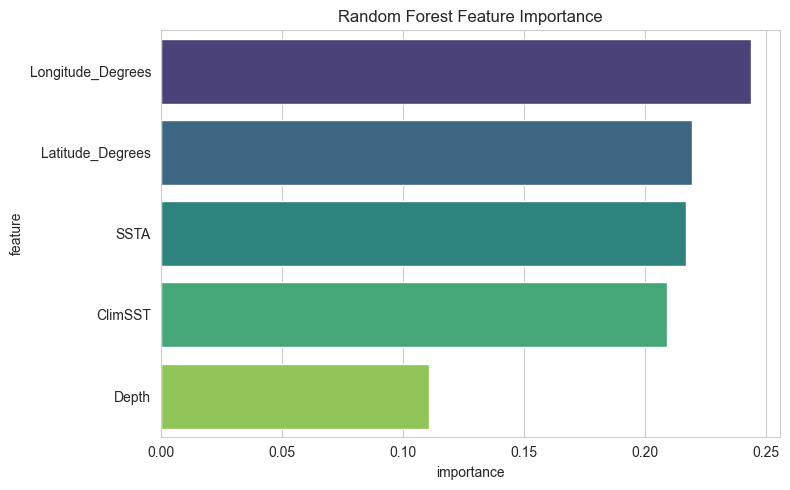

In [14]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature': PAPER_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 10. K-Fold Cross Validation (k=4)

เพิ่มจาก paper เพื่อดูว่า Random Forest baseline เสถียรแค่ไหนเมื่อแบ่งข้อมูลแบบ 4-fold

ใช้ hyperparameters เดียวกับ paper:
- `n_estimators=300`
- `max_depth=16`
- `max_features='sqrt'`
- `criterion='squared_error'`


In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    max_features='sqrt',
    criterion='squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_results = cross_validate(
    rf_cv,
    X,
    y,
    cv=cv,
    scoring={
        'r2': 'r2',
        'neg_mse': 'neg_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error'
    },
    n_jobs=-1,
    return_train_score=False
)

kfold_df = pd.DataFrame({
    'fold': range(1, 6),
    'R²': cv_results['test_r2'],
    'RMSE': np.sqrt(-cv_results['test_neg_mse']),
    'MAE': -cv_results['test_neg_mae']
})
kfold_df['Accuracy'] = 100 - kfold_df['MAE']

print("K-Fold Cross Validation (k=4):")
print(kfold_df.to_string(index=False))
print()
print(f"Mean R²:       {kfold_df['R²'].mean():.4f} ± {kfold_df['R²'].std():.4f}")
print(f"Mean RMSE:     {kfold_df['RMSE'].mean():.4f} ± {kfold_df['RMSE'].std():.4f}")
print(f"Mean MAE:      {kfold_df['MAE'].mean():.4f} ± {kfold_df['MAE'].std():.4f}")
print(f"Mean Accuracy: {kfold_df['Accuracy'].mean():.2f}% ± {kfold_df['Accuracy'].std():.2f}%")


K-Fold Cross Validation (k=4):
 fold       R²     RMSE      MAE  Accuracy
    1 0.166241 8.474094 3.389650 96.610350
    2 0.326003 8.268986 3.525597 96.474403
    3 0.301017 8.306308 3.362692 96.637308
    4 0.230545 8.176179 3.311425 96.688575
    5 0.343653 7.720916 3.376628 96.623372

Mean R²:       0.2735 ± 0.0738
Mean RMSE:     8.1893 ± 0.2832
Mean MAE:      3.3932 ± 0.0797
Mean Accuracy: 96.61% ± 0.08%


## 11. Robustness Check — Multiple Seeds

⚠️ **สำคัญมาก:** Paper ไม่ระบุ `random_state` ที่ใช้
ผลของ random 80/20 split จะแกว่งตาม seed (ที่เคยทดสอบ R² range 0.10-0.37)

ดังนั้นการ "reproduce paper" ที่ถูกต้องคือดู **ค่าเฉลี่ยข้ามหลาย seed** ไม่ใช่ค่าจาก seed เดียว


In [17]:
seeds = [0, 1, 7, 42, 100, 123, 2022, 2023]
results_seeds = []

for s in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    rf_s = RandomForestRegressor(
        n_estimators=300, max_depth=16, max_features='sqrt',
        criterion='squared_error', random_state=s, n_jobs=-1
    )
    rf_s.fit(Xtr, ytr)
    yp_s = rf_s.predict(Xte)
    r2_s = r2_score(yte, yp_s)
    rmse_s = np.sqrt(mean_squared_error(yte, yp_s))
    mae_s = mean_absolute_error(yte, yp_s)
    results_seeds.append({
        'seed': s, 'R²': r2_s, 'RMSE': rmse_s,
        'Accuracy': 100 - mae_s
    })

results_df = pd.DataFrame(results_seeds)
print(results_df.to_string(index=False))
print(f"\nMean R²:       {results_df['R²'].mean():.4f} ± {results_df['R²'].std():.4f}")
print(f"Mean RMSE:     {results_df['RMSE'].mean():.4f} ± {results_df['RMSE'].std():.4f}")
print(f"Mean Accuracy: {results_df['Accuracy'].mean():.2f}% ± {results_df['Accuracy'].std():.2f}%")
print(f"\nPaper:         R² = 0.25,  RMSE = 7.91,  Accuracy = 96%")
print(f"\n>>> ค่าเฉลี่ยควรใกล้เคียง paper")

 seed       R²     RMSE  Accuracy
    0 0.362861 8.567715 96.436022
    1 0.318622 7.030343 96.797463
    7 0.248779 8.747675 96.511640
   42 0.178583 8.411137 96.613096
  100 0.270353 7.843823 96.608211
  123 0.297925 8.680542 96.294224
 2022 0.239567 7.801177 96.842179
 2023 0.323008 8.658744 96.525280

Mean R²:       0.2800 ± 0.0580
Mean RMSE:     8.2176 ± 0.6062
Mean Accuracy: 96.58% ± 0.18%

Paper:         R² = 0.25,  RMSE = 7.91,  Accuracy = 96%

>>> ค่าเฉลี่ยควรใกล้เคียง paper


## 12. K-means Clustering (Figure 5)

ตาม paper:
> *"K-means grouped the data points into two distinct clusters and determined that a bleaching percentage of 30% or above was enough to classify a data point in the high-risk group"*


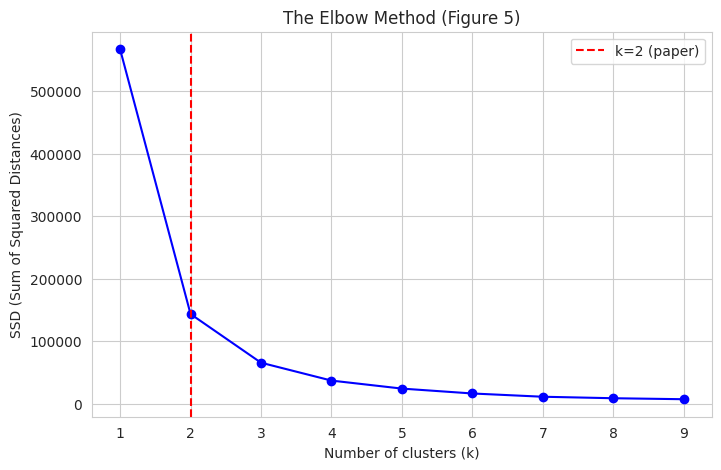

In [18]:
# Elbow method (Figure 5)
ssd = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(data[[TARGET]])
    ssd.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, ssd, 'b-o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSD (Sum of Squared Distances)')
plt.title('The Elbow Method (Figure 5)')
plt.axvline(2, color='red', linestyle='--', label='k=2 (paper)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# K-means กับ 2 clusters
km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
data = data.copy()
data['Cluster'] = km.fit_predict(data[[TARGET]])

# Label clusters: low risk = cluster ที่ mean ต่ำ
cluster_means = data.groupby('Cluster')[TARGET].mean().sort_values()
low_cluster = cluster_means.index[0]
data['Risk'] = data['Cluster'].map(
    lambda c: 'Low Risk' if c == low_cluster else 'High Risk'
)

print(data.groupby('Risk')[TARGET].agg(['count', 'mean', 'min', 'max']))

high_min = data[data['Risk'] == 'High Risk'][TARGET].min()
print(f"\nHigh-risk threshold: {high_min:.1f}%   (paper: ~30%)")

           count       mean    min    max
Risk                                     
High Risk    157  54.078822  28.75  100.0
Low Risk    5955   1.443158   0.00   27.5

High-risk threshold: 28.8%   (paper: ~30%)
